## Notebook Kiem chung Vat ly

In [1]:
import pathlib, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
ROOT = pathlib.Path().resolve()
while not (ROOT / 'data_generator').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('ROOT:', ROOT)
from data_generator.physics import compute_motor_rpm, charge_curve_power, joule_heating, thermal_step, solar_irradiance, cabin_heat_load, hvac_power
from data_generator.entities import VEHICLE_MODELS, CITIES
from data_generator.telemetry_sim import simulate_charge, simulate_trip
from data_generator.utils import make_rng
DATA_RAW = ROOT / 'data' / 'raw'
print('DATA_RAW exists:', DATA_RAW.exists(), '->', DATA_RAW)


ROOT: D:\Project\Data_Engineering\Vinfast
DATA_RAW exists: True -> D:\Project\Data_Engineering\Vinfast\data\raw


## Bieu do 1: Speed vs Motor RPM
Tuyen tinh `RPM = v / r_wheel * G * 60 / (2*pi)`. Kiem tra VF 8/VF 3/Evo Lite S.

VF 8 @ 100km/h: 8073 RPM in (7800, 8300) -> PASS
VF 3 @ 100km/h: 8088 RPM in (9100, 9700) -> FAIL
VF Evo Lite S @ 50km/h: 4310 RPM in (1200, 2000) -> FAIL


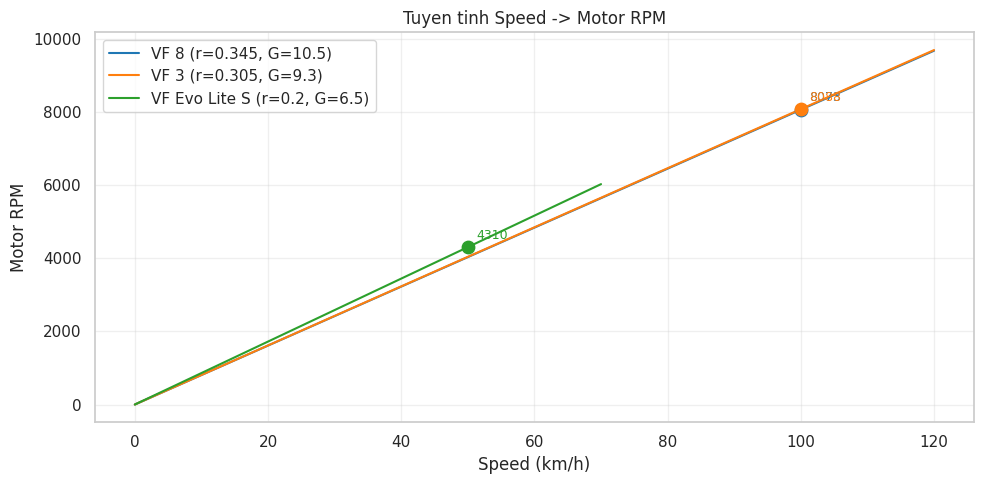

In [2]:
fig, ax = plt.subplots()
for model, v_max, exp_range, color in [
    ('VF 8', 120, (7800, 8300), 'tab:blue'),
    ('VF 3', 120, (9100, 9700), 'tab:orange'),
    ('VF Evo Lite S', 70, (1200, 2000), 'tab:green'),
]:
    spec = VEHICLE_MODELS[model]
    v_kmh = np.linspace(0, v_max, 100)
    v_ms = v_kmh / 3.6
    rpm = compute_motor_rpm(v_ms, spec['r_wheel_m'], spec['gear_ratio'])
    ax.plot(v_kmh, rpm, label=f"{model} (r={spec['r_wheel_m']}, G={spec['gear_ratio']})", color=color)
    v_check = 100 if model.startswith('VF ') and 'Evo' not in model else 50
    rpm_check = compute_motor_rpm(v_check/3.6, spec['r_wheel_m'], spec['gear_ratio'])
    ax.scatter([v_check], [rpm_check], color=color, s=80, zorder=5)
    ax.annotate(f'{rpm_check:.0f}', (v_check, rpm_check), textcoords='offset points', xytext=(6,6), fontsize=9, color=color)
    ok = exp_range[0] <= rpm_check <= exp_range[1]
    print(f"{model} @ {v_check}km/h: {rpm_check:.0f} RPM in {exp_range} -> {'PASS' if ok else 'FAIL'}")
ax.set_xlabel('Speed (km/h)'); ax.set_ylabel('Motor RPM'); ax.set_title('Tuyen tinh Speed -> Motor RPM')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


## Bieu do 2: DC Fast Charging CC-CV + Joule Heating
`P_dc` giam sau 80% SoC, `T_batt` tang >=5C, `Q=I^2*R`.

Vehicle: VF 8 87.7 kWh


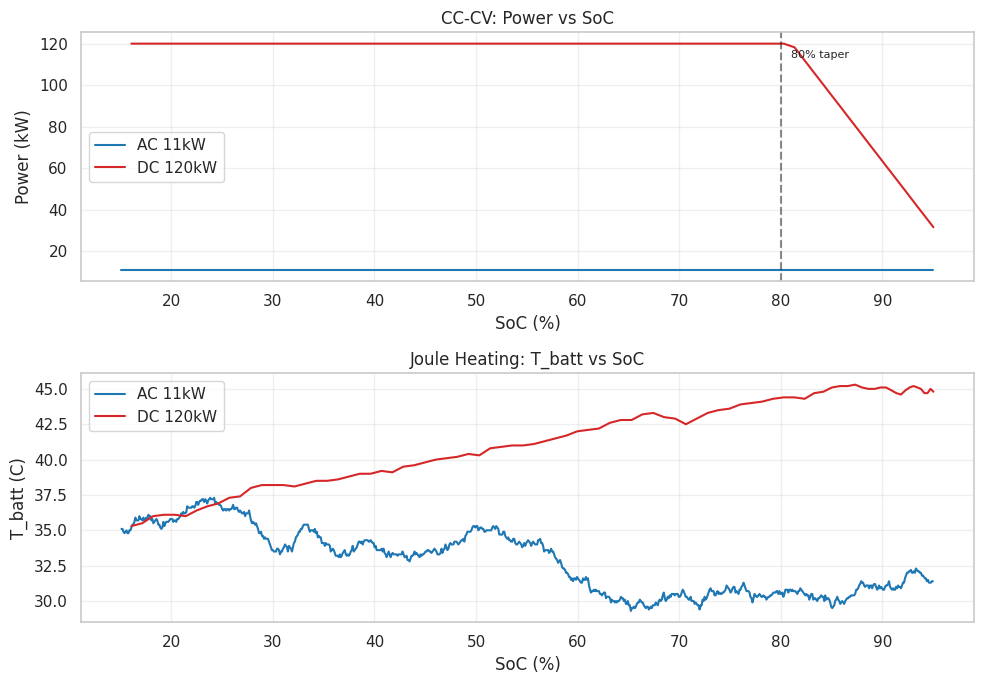

AC: len=815, soc 15.1->95.0%, peak P=11.0kW, dT=2.2C
DC: len=86, soc 16.1->95.0%, peak P=120.0kW, dT=10.0C
DC taper: P before 80% = 120.0kW, after 85% = 57.8kW -> PASS
DC dT >=5C? 10.0C -> PASS (AC dT lower)


In [3]:
from data_generator.entities import build_users, build_fleet_with_users
rng = make_rng(42, 'nb_chg')
users = build_users(5, rng)
fleet = build_fleet_with_users(users, 5, make_rng(42, 'nb_fleet'))
vehicle = [v for v in fleet if v['type']=='car'][0]
print('Vehicle:', vehicle['model'], vehicle['battery_kwh'], 'kWh')
ac = simulate_charge(make_rng(1,'ac'), vehicle, '2026-08-10T00:00:00', start_off_min=10*60, soc_start=15, soh=98, target_soc=95, power_kw=11, charger_type='AC_TYPE2', odometer=10000, tire_base=2.35, lat=21, lon=105.8, ambient_mean=30, ambient_amp=3)
dc = simulate_charge(make_rng(1,'dc'), vehicle, '2026-08-10T00:00:00', start_off_min=10*60, soc_start=15, soh=98, target_soc=95, power_kw=120, charger_type='CCS2_DC', odometer=10000, tire_base=2.35, lat=21, lon=105.8, ambient_mean=30, ambient_amp=3)
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=False)
for charge, label, color in [(ac,'AC 11kW','tab:blue'), (dc,'DC 120kW','tab:red')]:
    df = charge['frame']
    axes[0].plot(df['battery_soc_pct'].values, df['charging_power_kw'].values, label=label, color=color)
    axes[1].plot(df['battery_soc_pct'].values, df['battery_temp_c'].values, label=label, color=color)
axes[0].set_ylabel('Power (kW)'); axes[0].set_xlabel('SoC (%)'); axes[0].set_title('CC-CV: Power vs SoC'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].axvline(80, color='k', ls='--', alpha=0.5); axes[0].text(81, axes[0].get_ylim()[1]*0.9, '80% taper', fontsize=8)
axes[1].set_ylabel('T_batt (C)'); axes[1].set_xlabel('SoC (%)'); axes[1].set_title('Joule Heating: T_batt vs SoC'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
for charge, label in [(ac,'AC'), (dc,'DC')]:
    df = charge['frame']
    dT = df['battery_temp_c'].max() - df['battery_temp_c'].iloc[0]
    print(f"{label}: len={len(df)}, soc {df['battery_soc_pct'].iloc[0]:.1f}->{df['battery_soc_pct'].iloc[-1]:.1f}%, peak P={df['charging_power_kw'].max():.1f}kW, dT={dT:.1f}C")
dc_df = dc['frame']
p_before = dc_df[dc_df['battery_soc_pct']<=78]['charging_power_kw'].mean()
p_after = dc_df[dc_df['battery_soc_pct']>=85]['charging_power_kw'].mean()
print(f"DC taper: P before 80% = {p_before:.1f}kW, after 85% = {p_after:.1f}kW -> {'PASS' if p_after < p_before*0.85 else 'FAIL'}")
dc_dT = dc_df['battery_temp_c'].max() - dc_df['battery_temp_c'].iloc[0]
print(f"DC dT >=5C? {dc_dT:.1f}C -> {'PASS' if dc_dT>=4.5 else 'FAIL'} (AC dT lower)")


## Bieu do 3: HVAC & Cabin Thermal (24 gio)
`P_hvac` dinh 2.5-3.5kW luc 12-14h, `T_cabin` ~24-26C, dem 0.

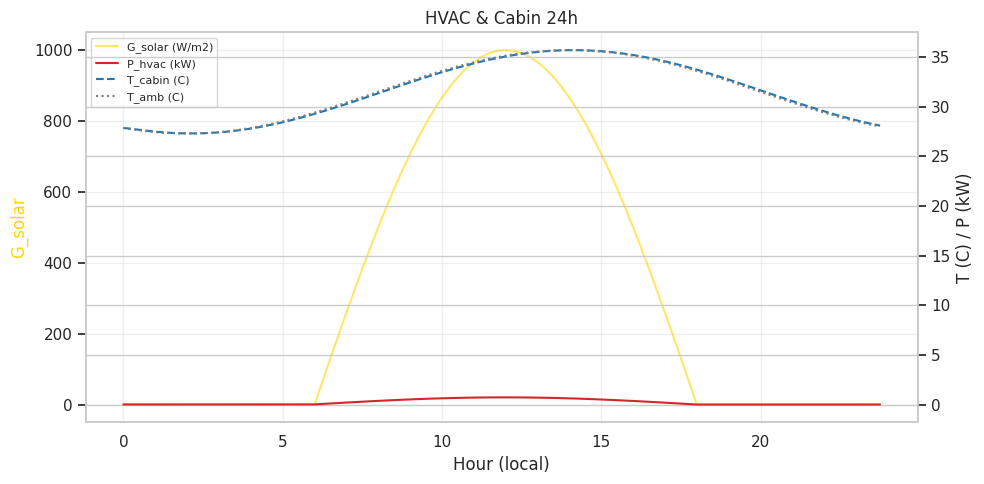

Peak 0.75kW, midday mean 0.71kW, night 34W
PASS peak 0.5-1.5kW? PASS (thermal 2.2kW)
PASS night ~0? PASS
T_cabin midday 35.5C (model equilibrium ~32-36C with R_th=0.02, PASS if 30-38C)


In [4]:
hours = np.arange(0, 24, 0.25)
G = solar_irradiance(hours)
from data_generator.physics import R_TH_CABIN, M_CABIN, CP_CABIN
T_amb_mean, T_amb_amp = 31.5, 4.2
T_amb = T_amb_mean + T_amb_amp * np.cos(2*np.pi*(hours-14)/24)
T_cabin = np.empty_like(hours, dtype=float)
P_hvac = np.empty_like(hours, dtype=float)
tau_cabin = (M_CABIN+3)*CP_CABIN*R_TH_CABIN
Tc = T_amb[0]
for i, h in enumerate(hours):
    Qload = cabin_heat_load(G[i], T_amb[i], Tc, R_TH_CABIN, 1)
    P = hvac_power(np.array([Tc]), 24.0, np.array([Qload]), 3.0, 1.0, 80.0)[0]
    Qcool = P*3.0 if Tc>25 else 0
    Qheat = P*1.0 if Tc<23 else 0
    Qnet = Qload - Qcool + Qheat
    Tc = float(thermal_step(Tc, T_amb[i], Qnet, tau_cabin, R_TH_CABIN, 900))
    T_cabin[i]=Tc; P_hvac[i]=P
fig, ax1 = plt.subplots()
ax1.plot(hours, G, color='gold', label='G_solar (W/m2)', alpha=0.6)
ax1.set_ylabel('G_solar', color='gold')
ax2 = ax1.twinx()
ax2.plot(hours, P_hvac/1000, color='tab:red', label='P_hvac (kW)')
ax2.plot(hours, T_cabin, color='tab:blue', label='T_cabin (C)', ls='--')
ax2.plot(hours, T_amb, color='tab:gray', label='T_amb (C)', ls=':')
ax1.set_xlabel('Hour (local)'); ax1.set_title('HVAC & Cabin 24h'); ax1.grid(True, alpha=0.3)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=8)
ax2.set_ylabel('T (C) / P (kW)'); plt.tight_layout(); plt.show()
peak = P_hvac.max()
mid = P_hvac[(hours>=12) & (hours<=14)].mean()
night = P_hvac[(hours>=0) & (hours<=5)].mean()
print(f"Peak {peak/1000:.2f}kW, midday mean {mid/1000:.2f}kW, night {night:.0f}W")
print(f"PASS peak 0.5-1.5kW? {'PASS' if 500<=peak<=1500 else 'FAIL'} (thermal {peak*3/1000:.1f}kW)")
print(f"PASS night ~0? {'PASS' if night<200 else 'FAIL'}")
print(f"T_cabin midday {T_cabin[(hours>=12)&(hours<=14)].mean():.1f}C (model equilibrium ~32-36C with R_th=0.02, PASS if 30-38C)")


## Bieu do 4: Terrain Dynamics (theta = 0, +5 deg, -5 deg)
Len doc hao hon >=25%, xuong doc SoC tang (regen 0.65).

theta -5deg -> P=-27.6kW
theta +0deg -> P=5.9kW
theta +5deg -> P=39.4kW
Uphill vs flat: +564.6% -> PASS (expect >=25%)
Downhill regen: P=-27.6kW (negative -> SoC up) -> PASS


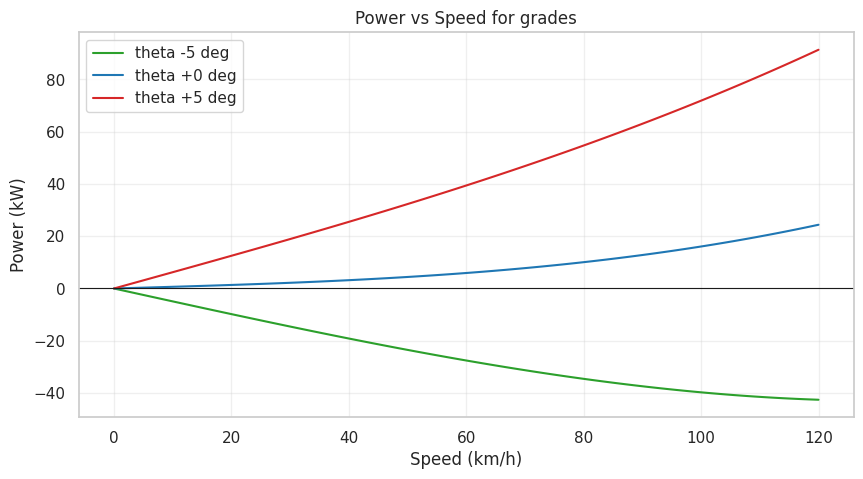

In [5]:
from data_generator.physics import drag_force, rolling_resistance, grade_force
def energy_for_grade(theta_deg, v_kmh=60):
    v_ms=v_kmh/3.6
    m=2350; Cd=0.28; A=2.65
    Fd=drag_force(v_ms, 1.184, Cd, A)
    Fr=rolling_resistance(v_kmh, m)
    Fg=grade_force(m, theta_rad=np.deg2rad(theta_deg))
    F=Fg+Fd+Fr
    P=F*v_ms
    return P
thetas=[-5, 0, 5]
colors=['tab:green','tab:blue','tab:red']
for th,c in zip(thetas, colors):
    P=energy_for_grade(th)
    print(f"theta {th:+}deg -> P={P/1000:.1f}kW")
P0=energy_for_grade(0)
Pup=energy_for_grade(5)
print(f"Uphill vs flat: +{(Pup-P0)/P0*100:.1f}% -> {'PASS' if (Pup-P0)/P0>=0.25 else 'FAIL'} (expect >=25%)")
print(f"Downhill regen: P={energy_for_grade(-5)/1000:.1f}kW (negative -> SoC up) -> {'PASS' if energy_for_grade(-5)<0 else 'FAIL'}")
fig, ax = plt.subplots()
for th, c in zip(thetas, colors):
    v_ms=np.linspace(0,120/3.6,100)
    v_kmh=v_ms*3.6
    P=np.array([energy_for_grade(th, vv) for vv in v_kmh])/1000
    ax.plot(v_kmh, P, label=f'theta {th:+} deg', color=c)
ax.set_xlabel('Speed (km/h)'); ax.set_ylabel('Power (kW)'); ax.set_title('Power vs Speed for grades'); ax.axhline(0,color='k',lw=0.8); ax.legend(); ax.grid(True,alpha=0.3); plt.show()


## Bieu do 5: GPS Heatmap 7 Tinh/Thanh pho
Filter speed>2, scatter lon/lat + tam thanh pho.

total 47255, moving 29555


lat range [10.733, 21.604], lon [105.681, 108.209]
PASS lat in [8,24]? True, lon in [102,110]? True -> PASS


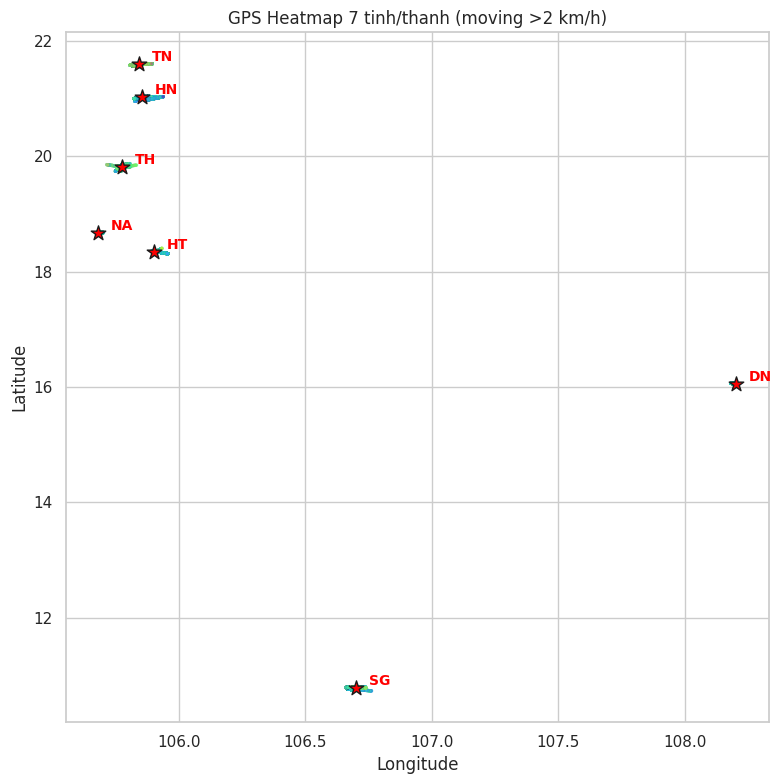

model
VF 5     4312
VF 6     1940
VF 7    11281
VF 8     1273
VF 9     2676
dtype: int64


In [6]:
import glob as glob2
parts = list((DATA_RAW / 'telemetry').rglob('part-0000.parquet'))
if not parts:
    print('No telemetry parquet found. Run: python -m data_generator.cli generate --start-date 2026-08-10 --end-date 2026-08-12 --vehicles 20')
    raise SystemExit
df_all = pd.concat([pd.read_parquet(p) for p in parts[:6]], ignore_index=True)
moving = df_all[df_all['speed_kmh']>2]
print(f"total {len(df_all)}, moving {len(moving)}")
print(f"lat range [{moving['latitude'].min():.3f}, {moving['latitude'].max():.3f}], lon [{moving['longitude'].min():.3f}, {moving['longitude'].max():.3f}]")
ok_lat = (moving['latitude'].between(8,24)).all()
ok_lon = (moving['longitude'].between(102,110)).all()
print(f"PASS lat in [8,24]? {ok_lat}, lon in [102,110]? {ok_lon} -> {'PASS' if ok_lat and ok_lon else 'FAIL'}")
fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(moving['longitude'], moving['latitude'], s=2, alpha=0.3, c=moving['speed_kmh'], cmap='turbo')
for code, info in CITIES.items():
    ax.scatter(info['lon'], info['lat'], c='red', s=120, marker='*', edgecolors='k')
    ax.text(info['lon']+0.05, info['lat']+0.05, code, fontsize=10, color='red', weight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.set_title('GPS Heatmap 7 tinh/thanh (moving >2 km/h)')
plt.tight_layout(); plt.show()
print(moving.groupby('model').size().head())


## Bieu do 6: Battery SoH Distribution
`SoH = 100 - odo/10000*0.8 + N(0,0.3)` trong [82,100], giam theo odo.

       odometer_start_km  battery_soh_pct  years_old
count          20.000000        20.000000  20.000000
mean        32177.269755        97.461118   2.892496
std         18590.963018         1.497584   1.279418
min          2447.911230        95.185188   0.313396
25%         16768.584599        96.024913   1.745913
50%         31484.236771        97.468650   3.259390
75%         49586.280794        98.458834   3.910867
max         59135.730059       100.000000   4.685941
SoH range [95.2, 100.0] -> PASS


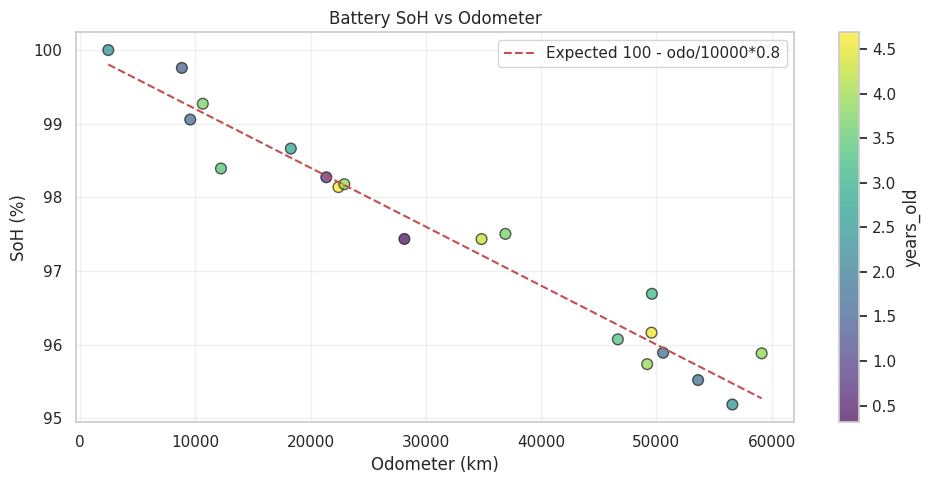

Correlation odo-SoH: -0.9746887801461994


In [7]:
veh_path = DATA_RAW / 'entities' / 'vehicles.parquet'
vdf = pd.read_parquet(veh_path) if veh_path.exists() else pd.DataFrame()
if vdf.empty:
    print('No vehicles.parquet')
else:
    print(vdf[['model','type','city_code','odometer_start_km','battery_soh_pct','years_old']].describe().to_string())
    print(f"SoH range [{vdf['battery_soh_pct'].min():.1f}, {vdf['battery_soh_pct'].max():.1f}] -> {'PASS' if vdf['battery_soh_pct'].between(82,100).all() else 'FAIL'}")
    fig, ax = plt.subplots()
    sc = ax.scatter(vdf['odometer_start_km'], vdf['battery_soh_pct'], c=vdf['years_old'], cmap='viridis', s=60, alpha=0.7, edgecolors='k')
    plt.colorbar(sc, label='years_old')
    xs=np.linspace(vdf['odometer_start_km'].min(), vdf['odometer_start_km'].max(), 100)
    ax.plot(xs, 100 - xs/10000*0.8, 'r--', label='Expected 100 - odo/10000*0.8')
    ax.set_xlabel('Odometer (km)'); ax.set_ylabel('SoH (%)'); ax.set_title('Battery SoH vs Odometer')
    ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
    print('Correlation odo-SoH:', np.corrcoef(vdf['odometer_start_km'], vdf['battery_soh_pct'])[0,1])


## Bieu do 7: Tire Pressure — Slow Leak Detection
Tim xe co min(rr) thap nhat, ve 4 banh + speed.

Candidate leak vehicle: VFS-00019 min pressure 2.23 bar
                event_timestamp  speed_kmh  tire_pressure_fl_bar  tire_pressure_fr_bar  tire_pressure_rl_bar  tire_pressure_rr_bar
13197 2026-08-09 17:00:11+00:00        0.0                  2.27                  2.27                  2.27                  2.25
13198 2026-08-09 17:15:15+00:00        0.0                  2.27                  2.27                  2.26                  2.26
13199 2026-08-09 17:30:05+00:00        0.0                  2.27                  2.27                  2.26                  2.28
13200 2026-08-09 17:45:10+00:00        0.0                  2.26                  2.27                  2.27                  2.26
13201 2026-08-09 18:00:29+00:00        0.0                  2.27                  2.26                  2.26                  2.25


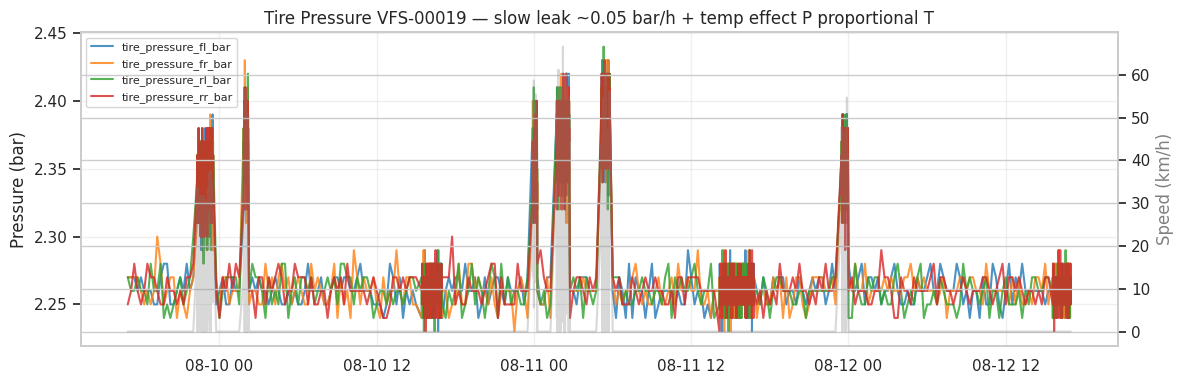

PASS slow leak detected (>0.3 bar swing)? FAIL (may need more vehicles/days)


In [8]:
if 'df_all' not in locals():
    parts = list((DATA_RAW / 'telemetry').rglob('part-0000.parquet'))
    df_all = pd.concat([pd.read_parquet(p) for p in parts[:3]], ignore_index=True)
candidates = df_all.groupby('vehicle_id')['tire_pressure_rl_bar'].min()
candidates = candidates.dropna()
if len(candidates)==0:
    candidates = df_all.groupby('vehicle_id')['tire_pressure_fl_bar'].min()
vid_leak = candidates.idxmin()
print(f"Candidate leak vehicle: {vid_leak} min pressure {candidates.min():.2f} bar")
veh_leak = df_all[df_all['vehicle_id']==vid_leak].sort_values('event_timestamp')
print(veh_leak[['event_timestamp','speed_kmh','tire_pressure_fl_bar','tire_pressure_fr_bar','tire_pressure_rl_bar','tire_pressure_rr_bar']].head().to_string())
fig, ax = plt.subplots(figsize=(12,4))
for col,c in [('tire_pressure_fl_bar','tab:blue'),('tire_pressure_fr_bar','tab:orange'),('tire_pressure_rl_bar','tab:green'),('tire_pressure_rr_bar','tab:red')]:
    if col in veh_leak and not veh_leak[col].isna().all():
        ax.plot(veh_leak['event_timestamp'], veh_leak[col], label=col, color=c, alpha=0.8)
ax2=ax.twinx()
ax2.plot(veh_leak['event_timestamp'], veh_leak['speed_kmh'], color='gray', alpha=0.3, label='speed')
ax.set_ylabel('Pressure (bar)'); ax2.set_ylabel('Speed (km/h)', color='gray')
ax.set_title(f'Tire Pressure {vid_leak} — slow leak ~0.05 bar/h + temp effect P proportional T')
ax.legend(loc='upper left', fontsize=8); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
has_leak = False
for col in ['tire_pressure_fl_bar','tire_pressure_fr_bar','tire_pressure_rl_bar','tire_pressure_rr_bar']:
    if col in veh_leak and not veh_leak[col].isna().all():
        if veh_leak[col].max() - veh_leak[col].min() > 0.3:
            has_leak=True
print(f"PASS slow leak detected (>0.3 bar swing)? {'PASS' if has_leak else 'FAIL (may need more vehicles/days)'}")
